In [2]:
import torch
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import os
import torchvision
import random
import matplotlib


In [3]:
device = ("cuda" if torch.cuda.is_available() else "cpu") # double quotes
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))
else:
    print("cpu")


Tesla T4


Start from train folder

        ↓
        
Scan all folders recursively

        ↓
        
Find folders containing "images"

        ↓
        
Loop through files in those folders

        ↓
        
Check if file is jpg/png/jpeg

        ↓
        
Create full path

        ↓
        
Store in list

In [4]:
basePath = "/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200/train"

# issue we faced: basePath = "/kaggle/input/datasets/akash2sharma/tiny-imagenet/" # giving error(means not doing anyhthing).. don't know the issue.
# correct: /kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200/train

imagePath=[] # will store all images path, of only train folder

for root,dirs,files in os.walk(basePath):
   
  if "train" in root:
    if "images" in root:
        for file in files:
            if file.endswith((".png",".jpg",".JPEG")):
                imagePath.append(os.path.join(root,file))
               


In [5]:
print(len(imagePath))

100000


In [6]:
# i=0;
# for p in imagePath:
#     if i == 10:
#         break
#     else:
#         print(p)
#     i+=1

for p in imagePath[:10]:
    print(p)

/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200/train/n02437312/images/n02437312_229.JPEG
/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200/train/n02437312/images/n02437312_394.JPEG
/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200/train/n02437312/images/n02437312_15.JPEG
/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200/train/n02437312/images/n02437312_62.JPEG
/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200/train/n02437312/images/n02437312_17.JPEG
/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200/train/n02437312/images/n02437312_158.JPEG
/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200/train/n02437312/images/n02437312_390.JPEG
/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200/train/n02437312/images/n02437312_323.JPEG
/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200/train/n02437312/images/n02437312_114.JPEG
/kaggle/input

In [7]:
from PIL import Image

image=Image.open(imagePath[0])

print(image)

# as the original image was 64 * 64, so later we will be resizing it.

<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=64x64 at 0x7AB4DB6F24E0>


In [8]:


imagetestPath=[] # will store all images path, of only test folder

# correct : /kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200, correct

# ours : /kaggle/input/tiny-imagenet/tiny-imagenet-200/test, wrong

for root,dirs,files in os.walk("/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200/test"):
   
  if "test" in root:
    if "images" in root:
        for file in files:
            if file.endswith((".png",".jpg",".JPEG")):
                imagetestPath.append(os.path.join(root,file))
               
               


In [9]:
print(len(imagetestPath))

10000


In [10]:

imagevalPath=[] # will store all images path, of only  val folder

for root,dirs,files in os.walk("/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200/val"):
  if "val" in root:
    if "images" in root:
        for file in files:
            if file.endswith((".png",".jpg",".JPEG")):
                imagevalPath.append(os.path.join(root,file))

In [11]:

print(len(imagevalPath))

10000


In [13]:
seed=42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed) 
torch.cuda.manual_seed_all(seed)

print("executed")

executed


In [205]:
#  # image and patch settings
#     IMAGE_SIZE = 224
#     PATCH_SIZE = 16
#     PATCH_DIM = PATCH_SIZE * PATCH_SIZE * 3  # (768)
#     NUM_PATCHES = 196    # (14x14)
#     MASK_RATIO = 0.75
#     NUM_VISIBLE = 49
#     NUM_MASKED = 147


# # encoder settings (ViT-Base B/16)
# #     ENC_EMBED_DIM = 768
# #     ENC_DEPTH = 12
# #     ENC_NUM_HEADS = 12
# #     ENC_MLP_RATIO = 4


# # decoder settings (ViT-Small S/16)
# #     DEC_EMBED_DIM = 384
# #     DEC_DEPTH = 12
# #     DEC_NUM_HEADS = 6
# #     DEC_MLP_RATIO = 4

# # training settings
BATCH_SIZE = 32
EPOCHS = 20
BASE_LR = 1.5e-4
WEIGHT_DECAY = 0.05
WARMUP_EPOCHS = 5
GRAD_CLIP = 1.0


In [14]:
from torchvision import transforms

# transform for training
transformTrain= transforms.Compose([
    transforms.Resize(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(), # convert into tensor and scaled it btw 0 and 1
    transforms.Normalize( mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
    
])

In [15]:
# transform for validation
transformVal= transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(), # convert into tensor and scaled it btw 0 and 1
    transforms.Normalize( mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
    
])

In [16]:
from PIL import Image

In [17]:
from torch.utils.data import Dataset, DataLoader

In [216]:
class customDataset(Dataset):

    def __init__(self,path,Transforms):
        self.paths=path
        self.Transforms=Transforms
        
    def __len__(self):
        return len(self.paths)
        
    def __getitem__(self,index):
       
        img_path = self.paths[index]
        img = Image.open(img_path).convert("RGB")
        img = self.Transforms(img)
        return img
      


        
        

      
        
        



In [218]:
train_Dataset=customDataset(imagePath,transformTrain)

In [217]:
val_Dataset = customDataset(imagevalPath,transformVal)

In [22]:
print(val_Dataset[0])

tensor([[[-0.8335, -0.8335, -0.8164,  ...,  0.3652,  0.3823,  0.3823],
         [-0.8335, -0.8335, -0.8164,  ...,  0.3652,  0.3823,  0.3823],
         [-0.8507, -0.8507, -0.8335,  ...,  0.3481,  0.3309,  0.3309],
         ...,
         [-0.2684, -0.2684, -0.2684,  ...,  0.0569,  0.0569,  0.0569],
         [-0.2856, -0.2856, -0.2856,  ...,  0.0398,  0.0398,  0.0398],
         [-0.2856, -0.2856, -0.2856,  ...,  0.0398,  0.0398,  0.0398]],

        [[-0.7052, -0.7052, -0.6877,  ...,  0.4328,  0.4503,  0.4503],
         [-0.7052, -0.7052, -0.6877,  ...,  0.4328,  0.4503,  0.4503],
         [-0.7227, -0.7227, -0.7052,  ...,  0.4153,  0.3978,  0.3978],
         ...,
         [-0.1450, -0.1450, -0.1450,  ...,  0.2927,  0.2927,  0.2927],
         [-0.1625, -0.1625, -0.1625,  ...,  0.2752,  0.2752,  0.2752],
         [-0.1625, -0.1625, -0.1625,  ...,  0.2752,  0.2752,  0.2752]],

        [[-0.5670, -0.5670, -0.5495,  ...,  0.4962,  0.5136,  0.5136],
         [-0.5670, -0.5670, -0.5495,  ...,  0

In [219]:
train_Dataloader=DataLoader(train_Dataset,batch_size=32,shuffle=True,pin_memory=True,drop_last=True,num_workers=4)


In [220]:
val_Dataloader=DataLoader(val_Dataset,batch_size=32,shuffle=True,pin_memory=True,num_workers=4)


In [25]:
print(len(train_Dataset))

100000


In [26]:
image=train_Dataset[0]
print(image)
print(image.shape)

tensor([[[ 0.6049,  0.6049,  0.6049,  ...,  1.1358,  1.1358,  1.1358],
         [ 0.6049,  0.6049,  0.6049,  ...,  1.1358,  1.1358,  1.1358],
         [ 0.6049,  0.6049,  0.6049,  ...,  1.1358,  1.1358,  1.1358],
         ...,
         [-1.9980, -1.9980, -1.9638,  ..., -1.9980, -1.9638, -1.9638],
         [-1.9809, -1.9809, -1.9467,  ..., -1.9638, -1.9124, -1.9124],
         [-1.9809, -1.9809, -1.9467,  ..., -1.9638, -1.9124, -1.9124]],

        [[ 1.3081,  1.3081,  1.3081,  ...,  1.5707,  1.5707,  1.5707],
         [ 1.3081,  1.3081,  1.3081,  ...,  1.5707,  1.5707,  1.5707],
         [ 1.3081,  1.3081,  1.3081,  ...,  1.5707,  1.5707,  1.5707],
         ...,
         [-1.6155, -1.6155, -1.5980,  ..., -1.8606, -1.8256, -1.8256],
         [-1.5980, -1.5980, -1.5630,  ..., -1.8256, -1.7731, -1.7731],
         [-1.5980, -1.5980, -1.5630,  ..., -1.8256, -1.7731, -1.7731]],

        [[ 1.5071,  1.5071,  1.5071,  ...,  1.7685,  1.7685,  1.7685],
         [ 1.5071,  1.5071,  1.5071,  ...,  1

images, labels = next(iter(train_dataloader))


it is an ITERATOR

→ iter()       converts dataloader to iterator

→ next()       grabs the next (first) batch

In [221]:
images = next(iter(train_Dataloader))

print(images.shape)

torch.Size([32, 3, 224, 224])


In [222]:
image=val_Dataset[0]
print(image)
print(image.shape)

tensor([[[-0.8335, -0.8335, -0.8164,  ...,  0.3652,  0.3823,  0.3823],
         [-0.8335, -0.8335, -0.8164,  ...,  0.3652,  0.3823,  0.3823],
         [-0.8507, -0.8507, -0.8335,  ...,  0.3481,  0.3309,  0.3309],
         ...,
         [-0.2684, -0.2684, -0.2684,  ...,  0.0569,  0.0569,  0.0569],
         [-0.2856, -0.2856, -0.2856,  ...,  0.0398,  0.0398,  0.0398],
         [-0.2856, -0.2856, -0.2856,  ...,  0.0398,  0.0398,  0.0398]],

        [[-0.7052, -0.7052, -0.6877,  ...,  0.4328,  0.4503,  0.4503],
         [-0.7052, -0.7052, -0.6877,  ...,  0.4328,  0.4503,  0.4503],
         [-0.7227, -0.7227, -0.7052,  ...,  0.4153,  0.3978,  0.3978],
         ...,
         [-0.1450, -0.1450, -0.1450,  ...,  0.2927,  0.2927,  0.2927],
         [-0.1625, -0.1625, -0.1625,  ...,  0.2752,  0.2752,  0.2752],
         [-0.1625, -0.1625, -0.1625,  ...,  0.2752,  0.2752,  0.2752]],

        [[-0.5670, -0.5670, -0.5495,  ...,  0.4962,  0.5136,  0.5136],
         [-0.5670, -0.5670, -0.5495,  ...,  0

In [223]:
images = next(iter(val_Dataloader))

print(images.shape)


torch.Size([32, 3, 224, 224])


In [224]:
def patchify(batch_features):
    batchLength=batch_features.shape[0]
    batch_features=batch_features.reshape(batchLength,3,14,16,14,16)
    batch_features=batch_features.permute(0,2,4,1,3,5)
    batch_features=batch_features.reshape(batchLength,14,14,768)
    batch_features=batch_features.reshape(batchLength,196,768)
    return batch_features
    

In [133]:
a = torch.randn(32, 3, 224, 224,device=device)
a.shape

torch.Size([32, 3, 224, 224])

In [134]:
a = patchify(a)
a.shape

torch.Size([32, 196, 768])

In [225]:
def unpatchify(batch_features):
    batchLength=batch_features.shape[0]
    batch_features=batch_features.reshape(batchLength,14,14,768)
    batch_features=batch_features.reshape(batchLength,14,14,3,16,16)
    batch_features=batch_features.permute(0,3,1,4,2,5)
    batch_features=batch_features.reshape(batchLength,3,14,16,14,16)
    batch_features=batch_features.reshape(batchLength,3,224,224)
    return batch_features
    

In [136]:
a = unpatchify(a)
a.shape
# a=  torch.randn(32,196)
# a.shape
# for val in a[:10]:
#     print(val)



torch.Size([32, 3, 224, 224])

In [35]:
idshuffle= torch.argsort(a)
print(idshuffle)

tensor([[ 83, 143,  17,  ..., 188,  53, 105],
        [ 65, 184, 104,  ...,  86, 182, 108],
        [100, 186, 151,  ..., 156,  71, 162],
        ...,
        [121, 128,  81,  ...,  25, 132,  14],
        [ 49,  89,  40,  ..., 117, 173,  35],
        [110,   8,  21,  ...,  89,  93,  58]])


In [36]:
# visibleP=(patch for patch in idshuffle[:49])
visibleP=idshuffle[:49]
print(visibleP)

tensor([[ 83, 143,  17,  ..., 188,  53, 105],
        [ 65, 184, 104,  ...,  86, 182, 108],
        [100, 186, 151,  ..., 156,  71, 162],
        ...,
        [121, 128,  81,  ...,  25, 132,  14],
        [ 49,  89,  40,  ..., 117, 173,  35],
        [110,   8,  21,  ...,  89,  93,  58]])


In [37]:
a=torch.zeros(32,196)
print(a)

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])


In [38]:
a[49:]=1
print(a)
# visible 0
# masked 1

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])


In [226]:
def random_masking(batch_features):
    batch_len = batch_features.shape[0]
    
    noise      = torch.randn(batch_len, 196,device=device)
    idshuffle  = torch.argsort(noise)
    ids_restore = torch.argsort(idshuffle)        
    
    visibleid  = idshuffle[:, :49]                
    
    USvisibleid = visibleid.unsqueeze(-1)
    Evisibleid = USvisibleid.expand(-1, -1, 768)
    visible_patches = torch.gather(batch_features, 1, Evisibleid) #Evisibleid as index
    
    binarymask = torch.zeros(batch_len , 196,device=device)
    binarymask[:, 49:] = 1  #0 means visible 1 mean mask                    
    
    return visible_patches, binarymask, ids_restore

In [109]:
a = torch.randn(32,196,768,device=device)
a.shape

torch.Size([32, 196, 768])

In [110]:
visible_patches, binarymask, ids_restore = random_masking(a)

print(visible_patches.shape)
print(binarymask.shape)
print(ids_restore.shape)

torch.Size([32, 49, 768])
torch.Size([32, 196])
torch.Size([32, 196])


In [227]:
import torch
import torch.nn as nn

class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim=768, num_heads=12, dropout=0.0):
        super().__init__()

        self.attn = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True  # allows (B, seq, dim)
        )

    def forward(self, x):
        # self-attention: query = key = value = x
        out, _ = self.attn(x, x, x)
        return out

In [229]:
class MLP(nn.Module):
    def __init__(self, dim=768, mlp_ratio=4, dropout=0.1):
        super().__init__()

        hidden_dim = dim * mlp_ratio

        self.net = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.net(x)

In [230]:
class TransformerBlock(nn.Module):
    def __init__(self, embed_dim=768, num_heads=12, mlp_ratio=4, dropout=0.1):
        super().__init__()

        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = MultiHeadSelfAttention(embed_dim, num_heads, dropout)

        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = MLP(embed_dim, mlp_ratio, dropout)

    def forward(self, x):

        # Attention block
        x = x + self.attn(self.norm1(x))
        # MLP block
        x = x + self.mlp(self.norm2(x))

        return x

In [231]:
class MAEEncoder(nn.Module):
    def __init__(self, embed_dim=768, depth=12, num_heads=12, mlp_ratio=4):
        super().__init__()

      
        self.pos_embed = nn.Parameter(torch.zeros(1, 196, embed_dim,device=device))
        self.blocks = nn.ModuleList([   # stack of Transformer blocks
            TransformerBlock(embed_dim, num_heads, mlp_ratio)
            for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)
    def forward(self, x):  # x shape: (B,196,768)
        x = x + self.pos_embed
        visible_tokens, mask, ids_restore = random_masking(x)
        for block in self.blocks:
            visible_tokens = block(visible_tokens)
        encoder_output = self.norm(visible_tokens)

        return encoder_output, mask, ids_restore

In [115]:
encoder = MAEEncoder()

# total_params = sum(p.numel() for p in encoder.parameters())
# print("Total parameters:", total_params)

In [116]:
summ=0
for p in encoder.parameters():
    summ=summ+p.numel()
print(summ)

85206528


In [232]:

class MAEDecoder(nn.Module):

    def __init__(self, enc_dim=768, dec_dim=384, depth=12, num_heads=6, mlp_ratio=4):
        super().__init__()

        # project encoder features (768 → 384)
        self.project = nn.Linear(enc_dim, dec_dim)

        # learnable mask token
        self.mask_token = nn.Parameter(torch.zeros(1,1,dec_dim,device=device))

        # positional embeddings
        self.pos_embed = nn.Parameter(torch.zeros(1,196,dec_dim,device=device))

        # transformer blocks
        self.blocks = nn.ModuleList([
            TransformerBlock(dec_dim, num_heads, mlp_ratio)
            for _ in range(depth)
        ])

        # normalization
        self.norm = nn.LayerNorm(dec_dim)

        # predict patch pixels
        self.head = nn.Linear(dec_dim, enc_dim)


    def forward(self, encoder_tokens, ids_restore):

        # encoder_tokens = (B,49,768)

        # Step 1: project features
        x = self.project(encoder_tokens)   # (B,49,384)

        B, N, D = x.shape

        # Step 2: create mask tokens
        num_mask = 196 - N
        mask_tokens = self.mask_token.repeat(B, num_mask, 1)

        # Step 3: combine tokens
        x = torch.cat([x, mask_tokens], dim=1)

        # Step 4: restore original order
        ids_restore = ids_restore.unsqueeze(-1).repeat(1,1,D)
        x = torch.gather(x, dim=1, index=ids_restore)

        # Step 5: add positional embedding
        x = x + self.pos_embed

        # Step 6: transformer blocks
        for block in self.blocks:
            x = block(x)

        # Step 7: normalization
        x = self.norm(x)

        # Step 8: predict pixels
        x = self.head(x)

        return x

In [120]:
decoder = MAEDecoder()

summ=0
for p in decoder.parameters():
    summ=summ+p.numel()
print(summ)

21960960


In [233]:
import torch
import torch.nn as nn

class MAE(nn.Module):

    def __init__(self, encoder, decoder):
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder

    def forward(self, image):

        # encoder
        encoder_out, mask, ids_restore = self.encoder(image)

        # decoder
        reconstructed_patches = self.decoder(encoder_out, ids_restore)

        return reconstructed_patches, mask

In [122]:
# encoder = MAEEncoder()
# decoder = MAEDecoder()

# model = MAE(encoder, decoder)
# model=model.to(device)

In [123]:
# total_params = 0

# for p in model.parameters():
#     if p.requires_grad:
#         total_params = total_params + p.numel()

# print("Total trainable parameters:", total_params)

Total trainable parameters: 107167488


In [138]:
# dummy_input = torch.randn(2, 3, 224, 224).to(device)
# dummy_input= patchify(dummy_input)
# dummy_input.shape

torch.Size([2, 196, 768])

In [139]:
# reconstructed_patches, mask = model(dummy_input)
# print(reconstructed_patches.shape)
# print(mask.shape)

torch.Size([2, 196, 768])
torch.Size([2, 196])


In [140]:
# reconstructed_patches=unpatchify(reconstructed_patches)
# print(reconstructed_patches.shape)

torch.Size([2, 3, 224, 224])


In [234]:
model = MAE(encoder, decoder)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if torch.cuda.device_count() > 1:
    print("Using GPUs:", list(range(torch.cuda.device_count())))
    model = torch.nn.DataParallel(model)

model = model.to(device)

Using GPUs: [0, 1]


In [235]:
def masked_mse_loss(original_image, reconstructed_patches, mask):
    # Step 1: convert original image to patches
    target_patches = patchify(original_image)   # (B,196,768)
    # Step 2: compute pixel-wise MSE
    mse = (reconstructed_patches - target_patches) ** 2   # (B,196,768)
    # Step 3: average pixel loss inside each patch
    per_patch_loss = mse.mean(dim=-1)   # (B,196)
    # Step 4: apply mask (only masked patches contribute)
    loss = (per_patch_loss * mask).sum() / mask.sum()

    return loss

In [236]:
no_decay = []
decay = []

for name, param in model.named_parameters():
    
    if not param.requires_grad:
        continue
        
    if "bias" in name or "norm" in name.lower():
        no_decay.append(param)
    else:
        decay.append(param)


optimizer = torch.optim.AdamW(
    [
        {"params": decay, "weight_decay": WEIGHT_DECAY},
        {"params": no_decay, "weight_decay": 0.0}
    ],
    lr=BASE_LR
)

In [237]:
from torch.amp import GradScaler

scaler = GradScaler("cuda")

In [238]:
import math

total_steps = EPOCHS * len(train_Dataloader)
warmup_steps = WARMUP_EPOCHS * len(train_Dataloader)


def cosine_lr(step):

    # warmup phase
    if step < warmup_steps:
        return step / warmup_steps

    # cosine decay phase
    progress = (step - warmup_steps) / (total_steps - warmup_steps)

    return 0.5 * (1 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS
)
scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer,
    lr_lambda=cosine_lr
)

In [239]:
from tqdm import tqdm

In [241]:
print(torch.cuda.device_count())

2


In [242]:
# clear GPU cache
torch.cuda.empty_cache()

# print GPU memory usage
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"GPU {i} memory allocated:",
              torch.cuda.memory_allocated(i) / 1024**3, "GB")


# history lists
train_loss_history = []
val_loss_history = []


for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    # ───────── TRAIN PHASE ─────────
    model.train()
    train_loss = 0

    train_bar = tqdm(train_Dataloader, desc="Training", leave=False)

    for images in train_bar:

        images = images.to(device)

        optimizer.zero_grad()

        with torch.amp.autocast("cuda"):

            patches = patchify(images)

            reconstructed_patches, mask = model(patches)

            loss = masked_mse_loss(images, reconstructed_patches, mask)


        # backward pass
        scaler.scale(loss).backward()

        # unscale before clipping
        scaler.unscale_(optimizer)

        # gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)

        # optimizer update
        scaler.step(optimizer)
        scaler.update()

        # LR scheduler step (per batch)
        scheduler.step()

        train_loss += loss.item()

        train_bar.set_postfix(loss=loss.item())


    # ───────── VALIDATION PHASE ─────────
    model.eval()
    val_loss = 0

    val_bar = tqdm(val_Dataloader, desc="Validation", leave=False)

    with torch.no_grad():

        for images in val_bar:

            images = images.to(device)

            patches = patchify(images)

            reconstructed_patches, mask = model(patches)

            loss = masked_mse_loss(images, reconstructed_patches, mask)

            val_loss += loss.item()

            val_bar.set_postfix(loss=loss.item())


    # average losses
    avg_train_loss = train_loss / len(train_Dataloader)
    avg_val_loss = val_loss / len(val_Dataloader)

    train_loss_history.append(avg_train_loss)
    val_loss_history.append(avg_val_loss)


    # current learning rate
    current_lr = optimizer.param_groups[0]["lr"]


    print(
        f"Epoch {epoch+1} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | "
        f"LR: {current_lr:.7f}"
    )


    # ───────── SAVE CHECKPOINT ─────────
    if (epoch + 1) % 10 == 0:

        torch.save(
            {
                "epoch": epoch + 1,
                "model_state": model.module.state_dict()
                if isinstance(model, torch.nn.DataParallel)
                else model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "train_loss": avg_train_loss,
                "val_loss": avg_val_loss,
            },
            f"mae_checkpoint_epoch_{epoch+1}.pth"
        )

GPU 0 memory allocated: 2.802840232849121 GB
GPU 1 memory allocated: 1.904202938079834 GB

Epoch 1/20


Epoch 1 | Train Loss: 0.8617 | Val Loss: 0.8419 | LR: 0.0000380

Epoch 2/20


Epoch 2 | Train Loss: 0.8342 | Val Loss: 0.8087 | LR: 0.0000680

Epoch 3/20


Epoch 3 | Train Loss: 0.7855 | Val Loss: 0.7343 | LR: 0.0000980

Epoch 4/20


Epoch 4 | Train Loss: 0.6527 | Val Loss: 0.5553 | LR: 0.0001280

Epoch 5/20


...

Epoch 16 | Train Loss: 0.3012 | Val Loss: 0.2849 | LR: 0.0000218

Epoch 17/20


Epoch 17 | Train Loss: 0.2950 | Val Loss: 0.2819 | LR: 0.0000120

Epoch 18/20


Epoch 18 | Train Loss: 0.2902 | Val Loss: 0.2771 | LR: 0.0000049

Epoch 19/20


Epoch 19 | Train Loss: 0.2873 | Val Loss: 0.2763 | LR: 0.0000009

Epoch 20/20


Epoch 20 | Train Loss: 0.2864 | Val Loss: 0.2748 | LR: 0.0000001


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0559826..2.9115968].


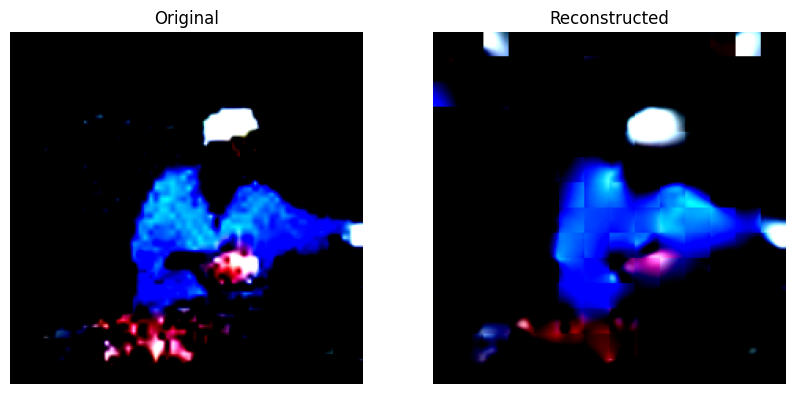

In [256]:
import matplotlib.pyplot as plt
import torch

model.eval()

img = Image.open(imagetestPath[5003]).convert("RGB")

img_tensor = transformTrain(img).unsqueeze(0).to(device)

with torch.no_grad():

    patches = patchify(img_tensor)

    reconstructed_patches, mask = model(patches)

    reconstructed_img = unpatchify(reconstructed_patches)

# move to cpu
original = img_tensor.cpu().squeeze().permute(1,2,0)
reconstructed = reconstructed_img.cpu().squeeze().permute(1,2,0)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(original)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Reconstructed")
plt.imshow(reconstructed)
plt.axis("off")

plt.show()